# Terminal Baires — Simulación de Eventos Discretos
### Procesos Estocásticos y Simulación · Grupo 07 · 2026 c1

**Objetivo.** Evaluar mediante simulación de eventos discretos (DES) la conveniencia de incorporar una **segunda grúa** al puerto, el efecto de una **política de mantenimiento preventivo**, y cuantificar el sobrecosto operativo de los **medio-contenedores** para decidir una **tarifa diferencial**.

Este notebook es **el sistema completo y reproducible**: parte de los datos históricos crudos, ajusta las distribuciones (*input analysis*), construye el simulador en **SimPy**, lo valida, corre el plan de experimentación con réplicas e intervalos de confianza, y deriva las conclusiones para las tres decisiones de gestión.

**Índice**
1. Input Analysis (depuración + ajuste de distribuciones + validación)
2. Modelo conceptual del simulador
3. Motor SimPy
4. Validación del motor
5. Plan de experimentación y resultados (4 escenarios, 30 réplicas, CRN)
6. VD1 — Segunda grúa (+ stress test de demanda)
7. VD2 — Tarifa diferencial por medio-contenedor
8. VD3 — Mantenimiento preventivo
9. Conclusiones

## 0. Setup

La celda busca los 4 archivos `tb_*.csv` automáticamente en varias ubicaciones (junto al notebook, en una subcarpeta `data/`, o un nivel arriba como `../data/`). Si no los encuentra, aborta con un mensaje indicando dónde buscó.

In [1]:
import simpy
import numpy as np, pandas as pd, math, time, os
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
# Carga robusta de CSV
plt.rcParams.update({'figure.dpi':110,'font.size':9,'axes.grid':True,'grid.alpha':.25})

FILES = ['tb_operaciones_grua.csv','tb_tiempos_amarre.csv','tb_registro_fallas.csv','tb_registro_clima.csv']
# El CSV puede estar junto al notebook, en una subcarpeta data/, o un nivel arriba
# (p. ej. notebook en notebooks/ y datos en ../data/). Se busca en orden.
SEARCH_DIRS = ['.', 'data', os.path.join('..','data'), '..']

def find_csv(name):
    for d in SEARCH_DIRS:
        p = os.path.join(d, name)
        if os.path.exists(p):
            return p
    return None

def load_csvs():
    paths = {nm: find_csv(nm) for nm in FILES}
    missing = [nm for nm, p in paths.items() if p is None]
    if missing:
        raise FileNotFoundError(
            f"Faltan estos CSV: {missing}. Buscados (relativo a '{os.getcwd()}') en: {SEARCH_DIRS}. "
            f"Poné los tb_*.csv junto al notebook o en una carpeta data/.")
    print("CSV cargados desde:", {nm: (os.path.dirname(paths[nm]) or '.') for nm in FILES})
    return tuple(pd.read_csv(paths[nm]) for nm in FILES)

g, a, f, c = load_csvs()
print("Operaciones grúa:", g.shape, "| Amarre:", a.shape, "| Fallas:", f.shape, "| Clima:", c.shape)

## 1. Input Analysis

El procedimiento: 

(1) depurar

(2) proponer distribuciones candidatas

(3) elegir por bondad de ajuste (test de Kolmogorov–Smirnov)

(4) validar contra anclas conocidas del enunciado.

### 1.1 Depuración

Buscamos faltantes, duplicados, valores imposibles (negativos), errores de tipo y atípicos.

In [3]:
from pandas.api.types import is_numeric_dtype
def depurar(name, df):
    print(f"== {name} ==  filas={len(df)}  faltantes={int(df.isna().sum().sum())}  dup={int(df.duplicated().sum())}")
    for col in df.columns:
        num = pd.to_numeric(df[col], errors='coerce')
        if num.notna().mean() > 0.5:
            s = num.dropna(); q1,q3 = np.percentile(s,[25,75]); iqr=q3-q1
            out = ((s<q1-3*iqr)|(s>q3+3*iqr)).sum()
            print(f"   {col:34s} min={s.min():8.2f} max={s.max():8.2f}  negativos={int((s<=0).sum())}  atípicos(3·IQR)={out}")
        else:
            print(f"   {col:34s} categorías={sorted(df[col].dropna().unique().tolist())}")
for nm,df in [("GRÚA",g),("AMARRE",a),("FALLAS",f),("CLIMA",c)]:
    depurar(nm,df); print()


== GRÚA ==  filas=2000  faltantes=0  dup=0
   ID_Movimiento                      categorías=['MOV-00001', 'MOV-00002', 'MOV-00003', 'MOV-00004', 'MOV-00005', 'MOV-00006', 'MOV-00007', 'MOV-00008', 'MOV-00009', 'MOV-00010', 'MOV-00011', 'MOV-00012', 'MOV-00013', 'MOV-00014', 'MOV-00015', 'MOV-00016', 'MOV-00017', 'MOV-00018', 'MOV-00019', 'MOV-00020', 'MOV-00021', 'MOV-00022', 'MOV-00023', 'MOV-00024', 'MOV-00025', 'MOV-00026', 'MOV-00027', 'MOV-00028', 'MOV-00029', 'MOV-00030', 'MOV-00031', 'MOV-00032', 'MOV-00033', 'MOV-00034', 'MOV-00035', 'MOV-00036', 'MOV-00037', 'MOV-00038', 'MOV-00039', 'MOV-00040', 'MOV-00041', 'MOV-00042', 'MOV-00043', 'MOV-00044', 'MOV-00045', 'MOV-00046', 'MOV-00047', 'MOV-00048', 'MOV-00049', 'MOV-00050', 'MOV-00051', 'MOV-00052', 'MOV-00053', 'MOV-00054', 'MOV-00055', 'MOV-00056', 'MOV-00057', 'MOV-00058', 'MOV-00059', 'MOV-00060', 'MOV-00061', 'MOV-00062', 'MOV-00063', 'MOV-00064', 'MOV-00065', 'MOV-00066', 'MOV-00067', 'MOV-00068', 'MOV-00069', 'MOV-00070

### 1.2 Ajuste de distribuciones (test KS)

In [4]:
def ks_rank(x, cands):
    out=[]
    for nm,d in cands.items():
        D,p = stats.kstest(x, d.cdf); out.append((nm,D,p))
    return sorted(out, key=lambda r:r[1])

def tri_moda(x):
    lo,hi,m = x.min(), x.max(), x.mean()
    return lo, hi, min(max(3*m-lo-hi, lo), hi)   # moda por momentos

def fit(x, label, lognorm=False, expon=False, uniform=False):
    lo,hi,mo = tri_moda(x)
    cands = {"Triangular":stats.triang((mo-lo)/(hi-lo),lo,hi-lo),
             "Normal":stats.norm(x.mean(),x.std(ddof=1))}
    if lognorm:
        s,_,sc = stats.lognorm.fit(x, floc=0); cands["LogNormal"]=stats.lognorm(s,0,sc)
    if expon:
        cands["Exponencial"]=stats.expon(0,x.mean())
    if uniform:
        cands["Uniforme"]=stats.uniform(lo,hi-lo)
    rk = ks_rank(x,cands)
    best = rk[0][0]
    alt = "  ".join(f"{nm}:{D:.3f}" for nm,D,p in rk[1:])   # alternativas (D ascendente) para ver el margen
    print(f">> {label:26s} n={len(x):4d}  media={x.mean():7.2f}  sd={x.std(ddof=1):6.2f}  | mejor: {best:11s} (KS={rk[0][1]:.3f}, p={rk[0][2]:.2f})  | otras→ {alt}")
    return best

# NOTA metodológica: el KS se aplica con parámetros estimados de la MISMA muestra,
# por lo que los p-valores son optimistas (conservadores): el test estándar supone
# parámetros conocidos a priori.

print("GRÚA — tiempo de operación por contenedor")
for t in ['Contenedor_Lleno','Medio_Contenedor']:
    fit(g.loc[g.Tipo_Unidad==t,'Tiempo_Operacion_min'].values, t)
print(f"   proporción medio-contenedor = {(g.Tipo_Unidad=='Medio_Contenedor').mean():.4f}\n")

print("AMARRE / DESAMARRE por tamaño de buque")
for sz in ['Chico','Mediano','Grande']:
    sub=a[a.Tamano_Buque==sz]
    fit(sub.Tiempo_Amarre_min.values, f"Amarre-{sz}")
    fit(sub.Tiempo_Desamarre_min.values, f"Desamarre-{sz}")
print(f"   mezcla tamaños = {a.Tamano_Buque.value_counts(normalize=True).round(3).to_dict()}\n")

print("FALLAS")
fit(f.MTBF_Minutos_Operativos.values, "MTBF (min operativos)", expon=True)
fit(f.MTTR_Tiempo_Reparacion_min.values, "MTTR (reparación)", lognorm=True)
print("\nCLIMA")
fit(c.Tiempo_Desde_Ultimo_Evento_dias.values, "Inter-evento clima (días)", expon=True)
fit(c.Duracion_Paro_Operativo_hs.values, "Duración del paro (hs)", uniform=True)


GRÚA — tiempo de operación por contenedor
>> Contenedor_Lleno           n=1615  media=  15.70  sd=  2.46  | mejor: Triangular  (KS=0.022, p=0.40)  | otras→ Normal:0.026
>> Medio_Contenedor           n= 385  media=  18.48  sd=  2.69  | mejor: Normal      (KS=0.027, p=0.94)  | otras→ Triangular:0.027
   proporción medio-contenedor = 0.1925

AMARRE / DESAMARRE por tamaño de buque
>> Amarre-Chico               n= 135  media=  21.29  sd=  2.78  | mejor: Triangular  (KS=0.055, p=0.79)  | otras→ Normal:0.059
>> Desamarre-Chico            n= 135  media=  18.82  sd=  3.00  | mejor: Normal      (KS=0.052, p=0.84)  | otras→ Triangular:0.056
>> Amarre-Mediano             n= 101  media=  42.19  sd=  5.30  | mejor: Normal      (KS=0.057, p=0.87)  | otras→ Triangular:0.084
>> Desamarre-Mediano          n= 101  media=  36.53  sd=  4.91  | mejor: Normal      (KS=0.043, p=0.99)  | otras→ Triangular:0.063
>> Amarre-Grande              n=  64  media=  61.69  sd=  7.52  | mejor: Normal      (KS=0.075, p=0.

'Uniforme'

**Distribuciones elegidas** (criterio: menor estadístico KS entre las candidatas):

| Variable | Distribución | Notas |
|---|---|---|
| Llegada de barcos | **Exponencial** (μ=3 días) | proceso de Poisson, ~10 barcos/mes (enunciado) |
| Op. grúa · contenedor lleno | **Triangular** (10,2 · 14,9 · 21,9) | media 15,7 min |
| Op. grúa · medio-contenedor | **Triangular** (12,3 · 18,4 · 24,8) | KS empata con Normal (D≈0,027 ambas); se elige Triangular por homogeneidad con el lleno. Media 18,5 min → **+17,7%** sobre el lleno → base de la tarifa (VD2) |
| Amarre/desamarre (×3 tamaños) | **Normal** | depende del porte; se usa Normal en los tres tamaños por homogeneidad (en Chico la Triangular ajusta marginalmente mejor; la Triangular falla en buques Grandes) |
| MTBF (entre fallas) | **Exponencial** (μ=1034 min op.) | fallas como proceso de Poisson en tiempo operativo |
| MTTR (reparación) | **LogNormal** | leve sesgo a derecha; valida la propuesta original |
| Inter-evento de clima | **Exponencial** (μ=11,1 días) | clima modelado como *eventos*, no como Bernoulli por paso |
| Duración del paro de clima | **Uniforme** (4,3 – 15,8 h) | la data es plana/algo bimodal; la Uniforme ajusta mejor que la Normal (KS D=0,131 vs 0,135) sin imponer una moda central. Media 10,0 h (preserva la indisponibilidad por clima) |

**Salvedad metodológica.** El KS se corre con **parámetros estimados de la misma muestra**, por lo que los p-valores son optimistas (el test estándar supone parámetros conocidos *a priori*. Lo usamos como **criterio comparativo** entre candidatas, no como prueba formal de bondad de ajuste. Los ajustes más flojos son la **duración del clima** (forma no-campana) y el **amarre de buques Grandes** (n=64): ambos de impacto acotado sobre las VR (el clima pesa ~3,6% del calendario y lo que importa es su duración media).

**Tres correcciones al modelo conceptual original**, surgidas de los datos: (1) el amarre **depende del tamaño** del buque (se incorpora como atributo); (2) el clima es un **proceso de eventos** (llegada Poisson + duración), no un Bernoulli por paso; (3) el MTTR efectivamente ajusta mejor a **LogNormal** (sesgo leve a derecha).

### 1.3 Validación de la calibración

In [5]:
indisp = f.MTTR_Tiempo_Reparacion_min.sum()/(f.MTBF_Minutos_Operativos.sum()+f.MTTR_Tiempo_Reparacion_min.sum())
frac_clima = (c.Duracion_Paro_Operativo_hs.mean()/24)/(c.Tiempo_Desde_Ultimo_Evento_dias.mean()+c.Duracion_Paro_Operativo_hs.mean()/24)
print(f"Indisponibilidad de grúa (ΣMTTR/Σtiempo) = {indisp:.4f}   →  objetivo del enunciado ≈ 0.15  ✓")
print(f"Proporción medio-contenedor               = {(g.Tipo_Unidad=='Medio_Contenedor').mean():.4f} →  objetivo ≈ 0.20  ✓")
print(f"Fracción de tiempo de calendario con clima adverso = {frac_clima:.4f} (~{frac_clima*100:.1f}%)")
ext = g.groupby('Tipo_Unidad').Tiempo_Operacion_min.mean()
print(f"Medio-contenedor es {100*(ext['Medio_Contenedor']/ext['Contenedor_Lleno']-1):.1f}% más lento que el lleno")


Indisponibilidad de grúa (ΣMTTR/Σtiempo) = 0.1485   →  objetivo del enunciado ≈ 0.15  ✓
Proporción medio-contenedor               = 0.1925 →  objetivo ≈ 0.20  ✓
Fracción de tiempo de calendario con clima adverso = 0.0362 (~3.6%)
Medio-contenedor es 17.7% más lento que el lleno


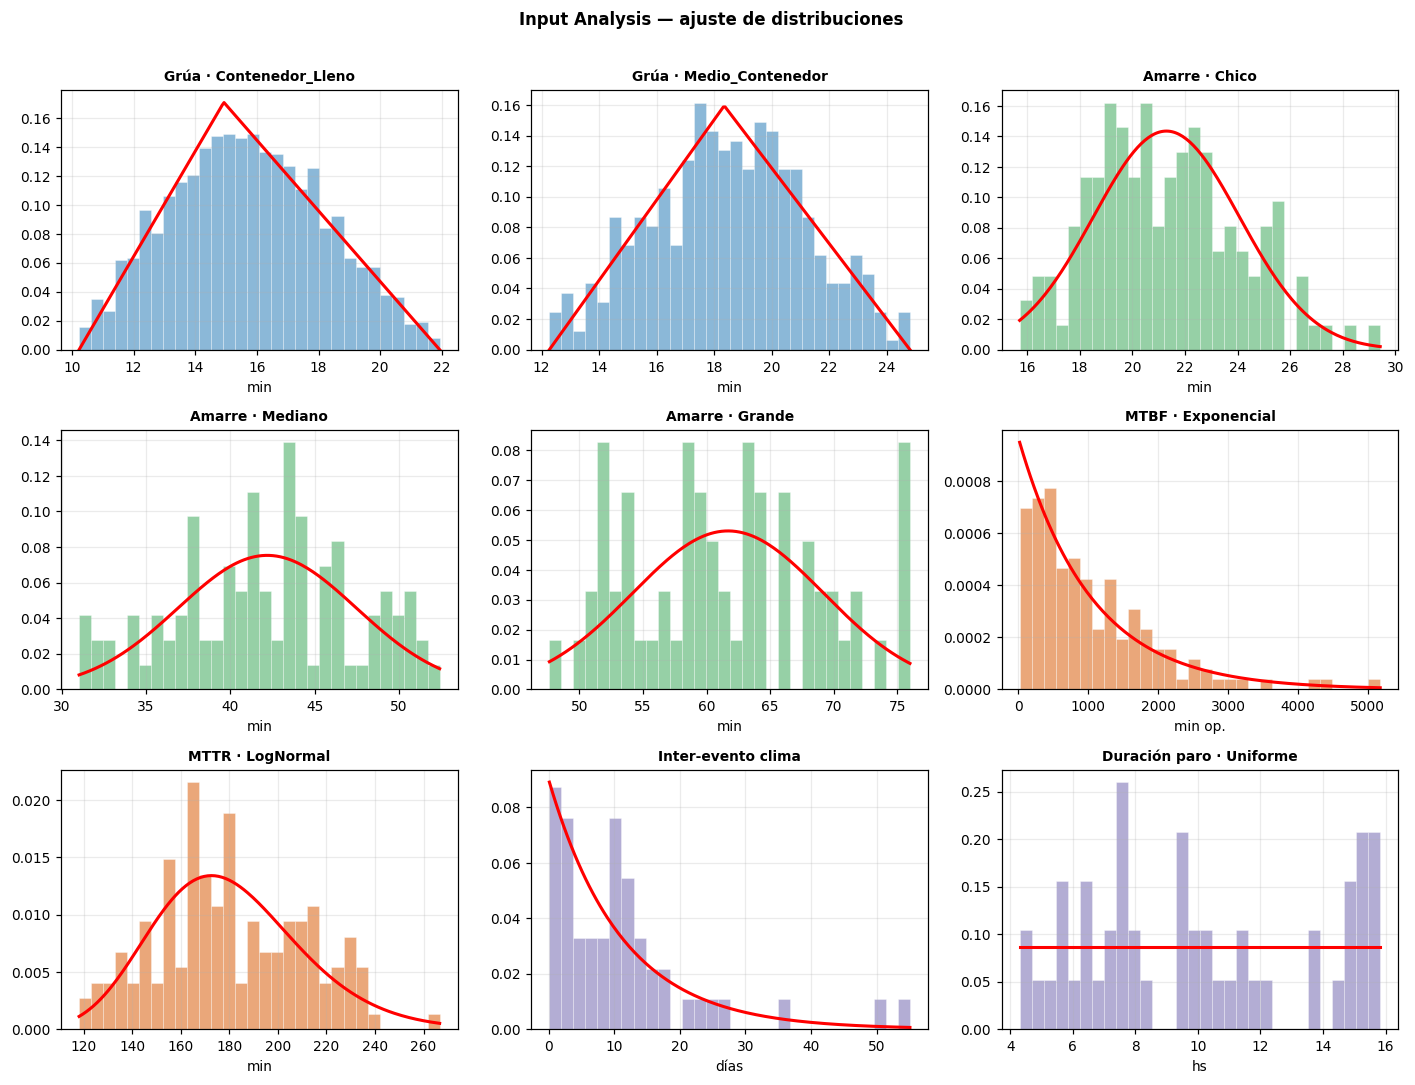

In [6]:
# Figura de ajustes (histograma + densidad ajustada)
fig,ax = plt.subplots(3,3,figsize=(13,10)); ax=ax.ravel()
def panel(i,x,frozen,tit,xl,col):
    ax[i].hist(x,bins=30,density=True,color=col,alpha=.55,edgecolor='white',lw=.4)
    xs=np.linspace(x.min(),x.max(),200); ax[i].plot(xs,frozen.pdf(xs),'r-',lw=2)
    ax[i].set_title(tit,fontsize=9,fontweight='bold'); ax[i].set_xlabel(xl)
for i,t in enumerate(['Contenedor_Lleno','Medio_Contenedor']):
    x=g.loc[g.Tipo_Unidad==t,'Tiempo_Operacion_min'].values; lo,hi,mo=tri_moda(x)
    panel(i,x,stats.triang((mo-lo)/(hi-lo),lo,hi-lo),f"Grúa · {t}","min",'#2c7fb8')
p=2
for sz in ['Chico','Mediano','Grande']:
    x=a.loc[a.Tamano_Buque==sz,'Tiempo_Amarre_min'].values
    panel(p,x,stats.norm(x.mean(),x.std(ddof=1)),f"Amarre · {sz}","min",'#41ab5d'); p+=1
x=f.MTBF_Minutos_Operativos.values; panel(5,x,stats.expon(0,x.mean()),"MTBF · Exponencial","min op.",'#d95f0e')
x=f.MTTR_Tiempo_Reparacion_min.values; s,_,sc=stats.lognorm.fit(x,floc=0)
panel(6,x,stats.lognorm(s,0,sc),"MTTR · LogNormal","min",'#d95f0e')
x=c.Tiempo_Desde_Ultimo_Evento_dias.values; panel(7,x,stats.expon(0,x.mean()),"Inter-evento clima","días",'#756bb1')
x=c.Duracion_Paro_Operativo_hs.values; panel(8,x,stats.uniform(x.min(),x.max()-x.min()),"Duración paro · Uniforme","hs",'#756bb1')
fig.suptitle("Input Analysis — ajuste de distribuciones",fontweight='bold'); fig.tight_layout(rect=[0,0,1,0.97]); plt.show()


### 1.4 Parámetros calibrados

In [7]:
DAY, MONTH, EPS = 1440.0, 30*1440.0, 1e-7
PAR = dict(
    interarribo_min = 3.0*DAY,
    grua_full = (10.23, 14.93, 21.93), grua_half = (12.27, 18.35, 24.81),
    prop_half = 0.20,
    sizes = ['Chico','Mediano','Grande'], size_p = [0.45, 0.3367, 0.2133],
    amarre   = {'Chico':(21.29,2.78),'Mediano':(42.19,5.30),'Grande':(61.69,7.52)},
    desamarre= {'Chico':(18.82,3.00),'Mediano':(36.53,4.91),'Grande':(55.27,7.88)},
    mtbf_min = 1033.8, mttr_s = 0.17, mttr_scale = 177.71,
    clima_gap_min = 11.12*DAY, clima_dur_lo_min = 4.30*60, clima_dur_hi_min = 15.83*60,  # duración Uniforme(min,max)
    cont_descarga = (5,10), cont_carga = (10,15),
)
print("Parámetros calibrados cargados.")


Parámetros calibrados cargados.


## 2. Modelo conceptual del simulador

**Entidad principal:** el *barco*, con atributos `tamaño` (Chico/Mediano/Grande), `#contenedores a descargar` U(5,10), `#contenedores a cargar` U(10,15) y, por contenedor, si es medio (Bernoulli p≈0,20).

**Recursos:** el *muelle* (capacidad 1, disciplina FCFS), la(s) *grúa(s)* (1 o 2 según escenario, con fallas independientes), y el *práctico* (capacidad ilimitada → se modela como demora, sin contención).

**Eventos / etapas:** llegada → cola en antepuerto → amarre → descarga → carga → desamarre → partida.

**Dos eventos estocásticos globales que interrumpen la operación:**
- **Clima adverso**: suspende *toda* operación del puerto (amarre, grúa, desamarre). Modelado como proceso de eventos: inter-llegada Exponencial(11,1 días) + duración Uniforme(4,3–15,8 h, media 10 h).
- **Falla de grúa**: interrumpe sólo la carga/descarga de la grúa afectada. El reloj de falla avanza en **minutos operativos** (MTBF Exp.), y la reparación toma MTTR (LogNormal). Por eso ~15% del *tiempo operativo* es indisponibilidad.

**Semántica de las dos grúas (VD1).** Como hay un único muelle, las dos grúas trabajan **el mismo barco en paralelo**: la lista de contenedores se reparte (round-robin) entre las grúas, cada una con **fallas independientes**. Si una falla, la otra continúa: el barco avanza a media velocidad en vez de detenerse.

**Mantenimiento preventivo (VD3).** No hay datos del régimen preventivo, por lo que se modela como un **supuesto declarado**: el preventivo multiplica el MTBF por 2,5 (fallas más espaciadas) y el MTTR por 0,7 (reparaciones más cortas). Se analiza su sensibilidad.

**Calidad estadística.**
- **RNG independientes por fuente** (llegadas, atributos, servicio, fallas, clima), todos derivados de la semilla de la réplica. Esto permite **Números Aleatorios Comunes (CRN)**: los 4 escenarios se corren con las **mismas semillas**, de modo que las diferencias entre escenarios se deben a la *política* y no al azar (reducción de varianza en las comparaciones pareadas).
- **Warm-up de 1 mes**: las observaciones previas se descartan mediante un *snapshot* al final del período de calentamiento.
- **30 réplicas** de **12 meses** cada una; se reportan media, desvío e **intervalo de confianza al 95%**.

## 3. Motor de simulación (SimPy)

El núcleo es la función `crane_work`, que sirve un monto de "trabajo-grúa" (minutos) y maneja, dentro del mismo bucle, las **pausas por clima** y las **interrupciones por falla** (medidas en minutos operativos). El amarre/desamarre usa `practico_work`, que sólo pausa por clima.

In [8]:

from dataclasses import dataclass

@dataclass
class Scenario:
    n_cranes: int = 1
    maint: bool = False
    prop_half: float = 0.20
    maint_mtbf_factor: float = 2.5
    maint_mttr_factor: float = 0.7
    weather: bool = True
    nombre: str = ""

class Streams:
    """RNG independientes por fuente estocástica → habilita CRN entre escenarios."""
    def __init__(self, seed):
        a,b,cc,d,e = np.random.SeedSequence(seed).spawn(5)
        self.arr=np.random.default_rng(a); self.ship=np.random.default_rng(b)
        self.svc=np.random.default_rng(cc); self.fail=np.random.default_rng(d)
        self.wx =np.random.default_rng(e); self.warmup=0.0

def tnorm(rng, media, sd):
    x=rng.normal(media,sd)
    while x<=0: x=rng.normal(media,sd)
    return x

class Crane:
    __slots__=('idx','up','ttf','op_time','downtime','n_fail')
    def __init__(self, idx, rng, P, sc):
        self.idx=idx; self.up=True
        self.ttf=rng.exponential(P['mtbf_min']*(sc.maint_mtbf_factor if sc.maint else 1.0))
        self.op_time=0.0; self.downtime=0.0; self.n_fail=0

class Port:
    def __init__(self, env):
        self.env=env; self.weather_ok=True
        self._clear=env.event(); self._break=env.event()
    def trigger_break(self):
        self.weather_ok=False; self._break.succeed(); self._break=self.env.event()
    def trigger_clear(self):
        self.weather_ok=True;  self._clear.succeed(); self._clear=self.env.event()

class Stats:
    def __init__(self):
        self.waits=[]; self.stays=[]; self.served=0; self.cont_moved=0
        self.half_extra=0.0; self.q_area=0.0; self.q_max=0; self.n_wait=0
        self._last=0.0; self.snap=None
    def touch(self, now): self.q_area += self.n_wait*(now-self._last); self._last=now
    def enqueue(self, now): self.touch(now); self.n_wait+=1; self.q_max=max(self.q_max,self.n_wait)
    def dequeue(self, now): self.touch(now); self.n_wait-=1

def sample_ship(rng, P):
    size=rng.choice(P['sizes'], p=P['size_p'])
    nU=int(rng.integers(P['cont_descarga'][0], P['cont_descarga'][1]+1))
    nL=int(rng.integers(P['cont_carga'][0],   P['cont_carga'][1]+1))
    return size,nU,nL

def container_times(S, nU, nL, P, sc):
    """Tiempos por contenedor + sobrecosto por medios (VD2).

    El sobrecosto de un medio se MIDE estocásticamente: su tiempo real de grúa
    menos el tiempo ESPERADO de un lleno (la media de la triangular del lleno).
    En valor esperado converge a meanH - meanF ≈ 2,78 min (+17,7%), el costo
    marginal real, y NO a la diferencia de modas (3,42 min), que sobreestimaría
    la base tarifaria. Así el extra es una medición de la sim, no una constante.
    """
    times=[]; extra=0.0; n_half=0
    fa,fm,fb=P['grua_full']; ha,hm,hb=P['grua_half']
    mean_full=(fa+fm+fb)/3.0   # tiempo esperado de un contenedor lleno (triangular)
    for _ in range(nU+nL):
        if S.ship.random() < sc.prop_half:
            t=S.svc.triangular(ha,hm,hb); times.append(t)
            extra += (t-mean_full); n_half+=1   # extra atribuible al medio
        else:
            times.append(S.svc.triangular(fa,fm,fb))
    return times, extra, n_half

def crane_work(env, crane, work, port, S, P, sc):
    remaining=work
    while remaining>EPS:
        while not port.weather_ok:           # pausa por clima
            yield port._clear
        t0=env.now
        res = yield env.timeout(remaining) | env.timeout(crane.ttf) | port._break
        elapsed=env.now-t0
        remaining-=elapsed; crane.ttf-=elapsed; crane.op_time+=elapsed
        if crane.ttf<=EPS and remaining>EPS:  # falla (en min operativos)
            crane.up=False; crane.n_fail+=1
            rep=S.fail.lognormal(math.log(P['mttr_scale']),P['mttr_s'])*(sc.maint_mttr_factor if sc.maint else 1.0)
            crane.downtime+=rep
            yield env.timeout(rep)
            crane.up=True
            crane.ttf=S.fail.exponential(P['mtbf_min']*(sc.maint_mtbf_factor if sc.maint else 1.0))

def practico_work(env, duration, port):
    remaining=duration
    while remaining>EPS:
        while not port.weather_ok: yield port._clear
        t0=env.now
        yield env.timeout(remaining) | port._break
        remaining-=(env.now-t0)

def ship_proc(env, size, nU, nL, port, muelle, cranes, S, st, P, sc):
    arrive=env.now; st.enqueue(env.now)
    with muelle.request() as req:
        yield req; st.dequeue(env.now)
        rec = arrive >= S.warmup
        if rec: st.waits.append(env.now-arrive)
        ma,msd=P['amarre'][size]
        yield from practico_work(env, tnorm(S.svc,ma,msd), port)        # amarre
        times,extra,_ = container_times(S,nU,nL,P,sc)
        loads=[0.0]*sc.n_cranes
        for i,t in enumerate(times): loads[i%sc.n_cranes]+=t
        procs=[env.process(crane_work(env,cranes[i],loads[i],port,S,P,sc))
               for i in range(sc.n_cranes) if loads[i]>EPS]
        if procs: yield env.all_of(procs)                              # descarga+carga
        if rec: st.cont_moved+=(nU+nL); st.half_extra+=extra
        da,dsd=P['desamarre'][size]
        yield from practico_work(env, tnorm(S.svc,da,dsd), port)        # desamarre
    if rec: st.stays.append(env.now-arrive); st.served+=1

def arrivals(env, port, muelle, cranes, S, st, P, sc):
    while True:
        yield env.timeout(S.arr.exponential(P['interarribo_min']))
        size,nU,nL=sample_ship(S.ship,P)
        env.process(ship_proc(env,size,nU,nL,port,muelle,cranes,S,st,P,sc))

def weather_proc(env, port, S, P, sc):
    if not sc.weather: return
    while True:
        yield env.timeout(S.wx.exponential(P['clima_gap_min']))
        port.trigger_break()
        yield env.timeout(S.wx.uniform(P['clima_dur_lo_min'],P['clima_dur_hi_min']))  # duración Uniforme
        port.trigger_clear()

def run_one(sc, seed, horizon_months=12, warmup_months=1, P=PAR, trace=False):
    env=simpy.Environment(); S=Streams(seed); S.warmup=warmup_months*MONTH
    port=Port(env); muelle=simpy.Resource(env,capacity=1)
    cranes=[Crane(i,S.fail,P,sc) for i in range(sc.n_cranes)]; st=Stats()
    env.process(arrivals(env,port,muelle,cranes,S,st,P,sc))
    env.process(weather_proc(env,port,S,P,sc))
    tr={'t':[], 'util':[], 'cola':[]}
    def snapshot():
        yield env.timeout(S.warmup); st.touch(env.now)
        st.snap=dict(q_area=st.q_area, op=[c.op_time for c in cranes], down=[c.downtime for c in cranes])
    env.process(snapshot())
    if trace:
        def monitor():
            while True:
                yield env.timeout(DAY/2)
                tr['t'].append(env.now/MONTH)
                tr['util'].append(sum(cc.op_time for cc in cranes)/(sc.n_cranes*max(env.now,1)))
                tr['cola'].append(st.n_wait)
        env.process(monitor())
    T=(warmup_months+horizon_months)*MONTH; env.run(until=T); st.touch(T)
    post=horizon_months*MONTH
    op_post  =sum(c.op_time for c in cranes)-sum(st.snap['op'])
    down_post=sum(c.downtime for c in cranes)-sum(st.snap['down'])
    q_post   =st.q_area-st.snap['q_area']
    out=dict(
        VR1_espera_h=np.mean(st.waits)/60 if st.waits else 0.0,
        VR2_estadia_h=np.mean(st.stays)/60 if st.stays else 0.0,
        VR2_max_h=np.max(st.stays)/60 if st.stays else 0.0,
        VR3_util=op_post/(sc.n_cranes*post),
        VR4_barcos_mes=st.served/horizon_months,
        VR4_cont_mes=st.cont_moved/horizon_months,
        VR5_cola_prom=q_post/post, VR5_cola_max=st.q_max,
        VR6_perdido_h=down_post/60, VD2_extra_medios_h=st.half_extra/60,
        _waits=st.waits, _stays=st.stays)
    if trace: out['trace']=tr
    return out
print("Motor SimPy cargado.")


Motor SimPy cargado.


## 4. Validación del motor

Antes de confiar en los resultados, verificamos que el simulador **reproduce las anclas conocidas**: una corrida larga (sin warm-up) debe dar ≈15% de indisponibilidad de grúa, ≈10 barcos/mes, y MTBF/MTTR realizados consistentes con la calibración.

In [9]:
env=simpy.Environment(); S=Streams(2024); S.warmup=0
port=Port(env); muelle=simpy.Resource(env,1); sc=Scenario(n_cranes=1, nombre="val")
cranes=[Crane(0,S.fail,PAR,sc)]; st=Stats()
env.process(arrivals(env,port,muelle,cranes,S,st,PAR,sc))
env.process(weather_proc(env,port,S,PAR,sc))
env.run(until=1200*MONTH); st.touch(1200*MONTH)
op,down,nf = cranes[0].op_time, cranes[0].downtime, cranes[0].n_fail
print(f"Indisponibilidad grúa  = {down/(op+down):.4f}   (objetivo 0.15)  ✓")
print(f"Barcos servidos / mes  = {st.served/1200:.2f}   (objetivo ~10)   ✓")
print(f"MTBF realizado (op)    = {op/nf:.0f} min        (objetivo 1034)  ✓")
print(f"MTTR realizado         = {down/nf:.0f} min       (objetivo 180)   ✓")


Indisponibilidad grúa  = 0.1474   (objetivo 0.15)  ✓
Barcos servidos / mes  = 9.84   (objetivo ~10)   ✓
MTBF realizado (op)    = 1044 min        (objetivo 1034)  ✓
MTTR realizado         = 181 min       (objetivo 180)   ✓


## 5. Plan de experimentación y resultados

Cuatro escenarios, cada uno con **30 réplicas** de **12 meses** + 1 mes de warm-up, usando **las mismas semillas** en los cuatro (CRN).

- **Base**: 1 grúa, sin mantenimiento
- **A**: 2 grúas, sin mantenimiento (VD1)
- **B**: 1 grúa, con mantenimiento (VD3)
- **C**: 2 grúas, con mantenimiento (combinado)

In [10]:
ESCENARIOS = {
 'Base': Scenario(1, False, nombre='Base'),
 'A'   : Scenario(2, False, nombre='A'),
 'B'   : Scenario(1, True,  nombre='B'),
 'C'   : Scenario(2, True,  nombre='C'),
}
SEEDS = list(range(30))   # CRN
def ic95(v): return 1.96*np.std(v,ddof=1)/np.sqrt(len(v))

t0=time.time()
RES = {nm:[run_one(sc, seed=s) for s in SEEDS] for nm,sc in ESCENARIOS.items()}
print(f"120 réplicas corridas en {time.time()-t0:.1f}s\n")

METR = [('VR1_espera_h','VR1 Espera antepuerto (h)'),
        ('VR2_estadia_h','VR2 Estadía total (h)'),
        ('VR3_util','VR3 Utilización grúa'),
        ('VR4_barcos_mes','VR4 Barcos/mes'),
        ('VR4_cont_mes','VR4 Contenedores/mes'),
        ('VR5_cola_prom','VR5 Cola promedio'),
        ('VR5_cola_max','VR5 Cola máxima'),
        ('VR6_perdido_h','VR6 Tiempo perdido fallas (h/año)')]
rows=[]
for key,lab in METR:
    row={'Variable de referencia':lab}
    for nm in ESCENARIOS:
        v=[r[key] for r in RES[nm]]
        row[nm]=f"{np.mean(v):.2f} ± {ic95(v):.2f}"
    rows.append(row)
tabla=pd.DataFrame(rows).set_index('Variable de referencia')
tabla


120 réplicas corridas en 1.7s



,Base,A,B,C
Variable de referencia,,,,
VR1 Espera antepuerto (h),0.60 ± 0.08,0.26 ± 0.04,0.48 ± 0.06,0.20 ± 0.03
VR2 Estadía total (h),8.64 ± 0.16,5.51 ± 0.11,7.83 ± 0.14,4.84 ± 0.09
VR3 Utilización grúa,0.07 ± 0.00,0.04 ± 0.00,0.07 ± 0.00,0.04 ± 0.00
VR4 Barcos/mes,9.74 ± 0.27,9.74 ± 0.27,9.74 ± 0.27,9.74 ± 0.27
VR4 Contenedores/mes,195.44 ± 5.71,195.47 ± 5.68,195.51 ± 5.72,195.44 ± 5.67
VR5 Cola promedio,0.01 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.00 ± 0.00
VR5 Cola máxima,1.60 ± 0.20,1.30 ± 0.17,1.47 ± 0.18,1.13 ± 0.12
VR6 Tiempo perdido fallas (h/año),110.19 ± 8.22,111.67 ± 8.44,30.70 ± 2.29,32.13 ± 3.52


**Lectura de la tabla.** Lo primero que salta a la vista es que **el sistema está muy holgado** a la demanda actual: la utilización de la grúa ronda el **7%** y la cola en el antepuerto es prácticamente **nula**. El puerto no está congestionado; tiene enorme capacidad ociosa.

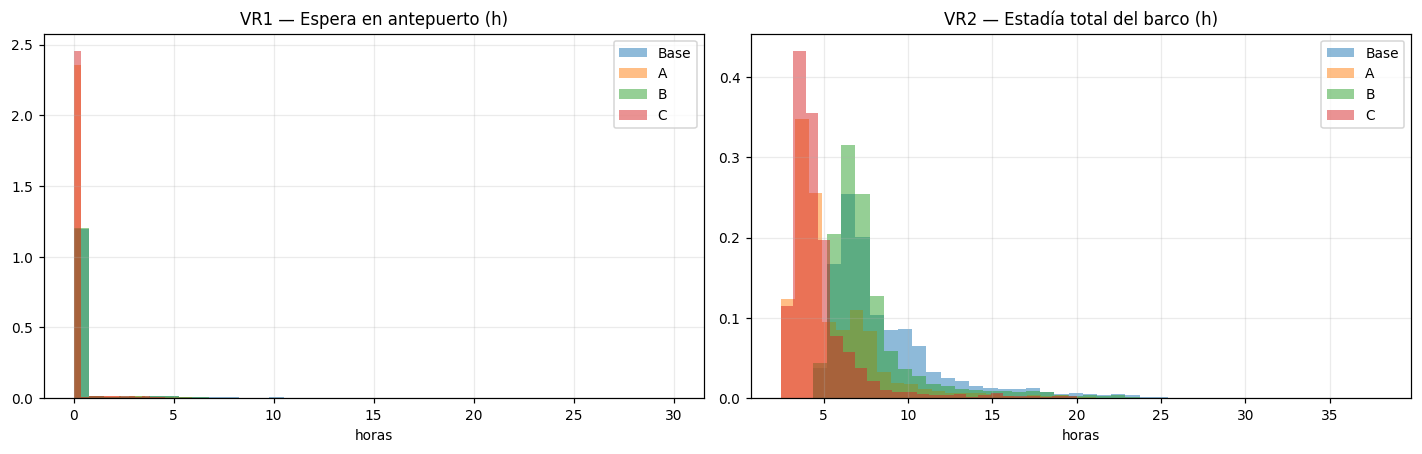

In [11]:
# Histogramas VR1 y VR2 por escenario
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
for nm in ESCENARIOS:
    w=np.concatenate([np.array(r['_waits'])/60 for r in RES[nm]])
    s=np.concatenate([np.array(r['_stays'])/60 for r in RES[nm]])
    ax[0].hist(w,bins=40,alpha=.5,label=nm,density=True)
    ax[1].hist(s,bins=40,alpha=.5,label=nm,density=True)
ax[0].set_title("VR1 — Espera en antepuerto (h)"); ax[0].set_xlabel("horas"); ax[0].legend()
ax[1].set_title("VR2 — Estadía total del barco (h)"); ax[1].set_xlabel("horas"); ax[1].legend()
plt.tight_layout(); plt.show()


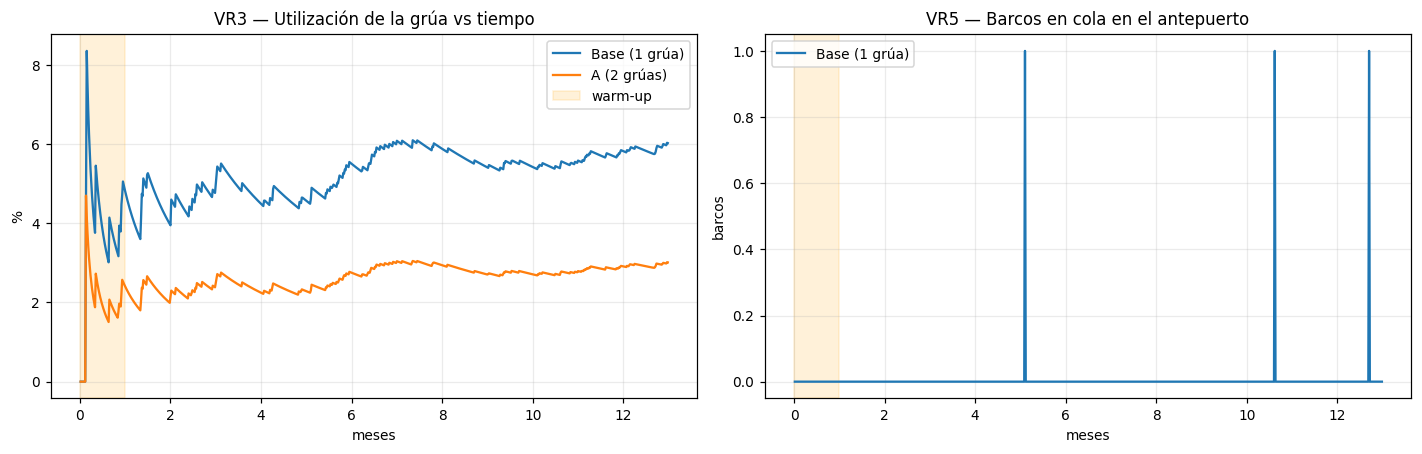

In [12]:
# Series temporales con warm-up visible (VR3 utilización y VR5 cola) — réplica representativa
tb=run_one(ESCENARIOS['Base'], seed=7, trace=True)['trace']
ta=run_one(ESCENARIOS['A'],    seed=7, trace=True)['trace']
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
ax[0].plot(tb['t'],np.array(tb['util'])*100,label='Base (1 grúa)')
ax[0].plot(ta['t'],np.array(ta['util'])*100,label='A (2 grúas)')
ax[0].axvspan(0,1,color='orange',alpha=.15,label='warm-up'); ax[0].set_title("VR3 — Utilización de la grúa vs tiempo")
ax[0].set_xlabel("meses"); ax[0].set_ylabel("%"); ax[0].legend()
ax[1].plot(tb['t'],tb['cola'],label='Base (1 grúa)'); ax[1].axvspan(0,1,color='orange',alpha=.15)
ax[1].set_title("VR5 — Barcos en cola en el antepuerto"); ax[1].set_xlabel("meses"); ax[1].set_ylabel("barcos"); ax[1].legend()
plt.tight_layout(); plt.show()


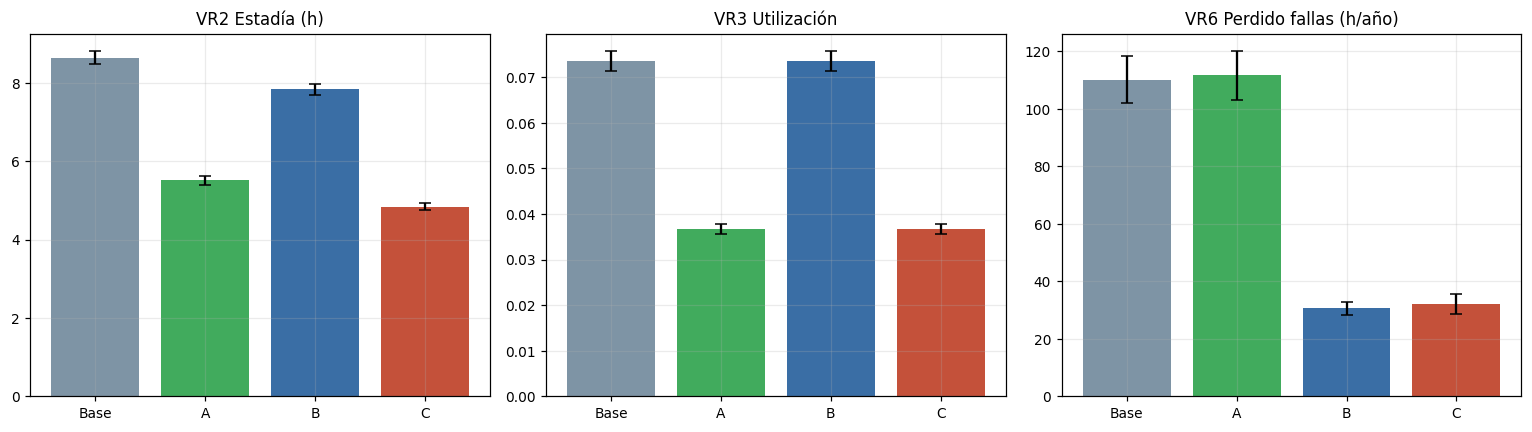

In [13]:
# Barras comparativas con IC95 para las VR principales
fig,ax=plt.subplots(1,3,figsize=(14,4))
for j,(key,lab) in enumerate([('VR2_estadia_h','VR2 Estadía (h)'),
                              ('VR3_util','VR3 Utilización'),
                              ('VR6_perdido_h','VR6 Perdido fallas (h/año)')]):
    m=[np.mean([r[key] for r in RES[nm]]) for nm in ESCENARIOS]
    e=[ic95([r[key] for r in RES[nm]]) for nm in ESCENARIOS]
    ax[j].bar(list(ESCENARIOS),m,yerr=e,capsize=4,
              color=['#7E94A5','#41ab5d','#3A6EA5','#C4513A'])
    ax[j].set_title(lab)
plt.tight_layout(); plt.show()


## 6. VD1 — ¿Conviene la segunda grúa?

La comparación **pareada por CRN** (mismo azar, sólo cambia la política) aísla el efecto de la segunda grúa.

In [14]:
base=np.array([r['VR2_estadia_h'] for r in RES['Base']])
A   =np.array([r['VR2_estadia_h'] for r in RES['A']])
d=base-A
print(f"Reducción de estadía 1→2 grúas = {d.mean():.2f} h  (IC95 ±{ic95(d):.2f})  ≈ {100*d.mean()/base.mean():.0f}%")
print(f"Espera en antepuerto Base = {np.mean([r['VR1_espera_h'] for r in RES['Base']]):.2f} h  →  A = {np.mean([r['VR1_espera_h'] for r in RES['A']]):.2f} h")
print("La 2da grúa parte cada operación en paralelo: baja la ESTADÍA, pero la espera ya era casi nula (no hay congestión que aliviar).")


Reducción de estadía 1→2 grúas = 3.13 h  (IC95 ±0.11)  ≈ 36%
Espera en antepuerto Base = 0.60 h  →  A = 0.26 h
La 2da grúa parte cada operación en paralelo: baja la ESTADÍA, pero la espera ya era casi nula (no hay congestión que aliviar).


### 6.1 Stress test: ¿a qué demanda se justificaría?

Como a la demanda actual no hay congestión, la pregunta relevante es **hasta qué nivel de tráfico** el puerto sigue holgado. Barremos la tasa de llegadas.

,barcos_mes,estadia_1g,estadia_2g,cola_1g,cola_2g,util_1g
0,10,8.64,5.51,0.01,0.00,0.07
1,14,8.79,5.56,0.02,0.01,0.10
2,18,9.08,5.67,0.03,0.01,0.13
3,22,9.36,5.76,0.04,0.02,0.16
4,26,9.67,5.86,0.06,0.03,0.19
5,30,10.11,6.02,0.09,0.03,0.22
6,40,11.43,6.38,0.20,0.07,0.30
7,50,12.95,6.81,0.35,0.12,0.37


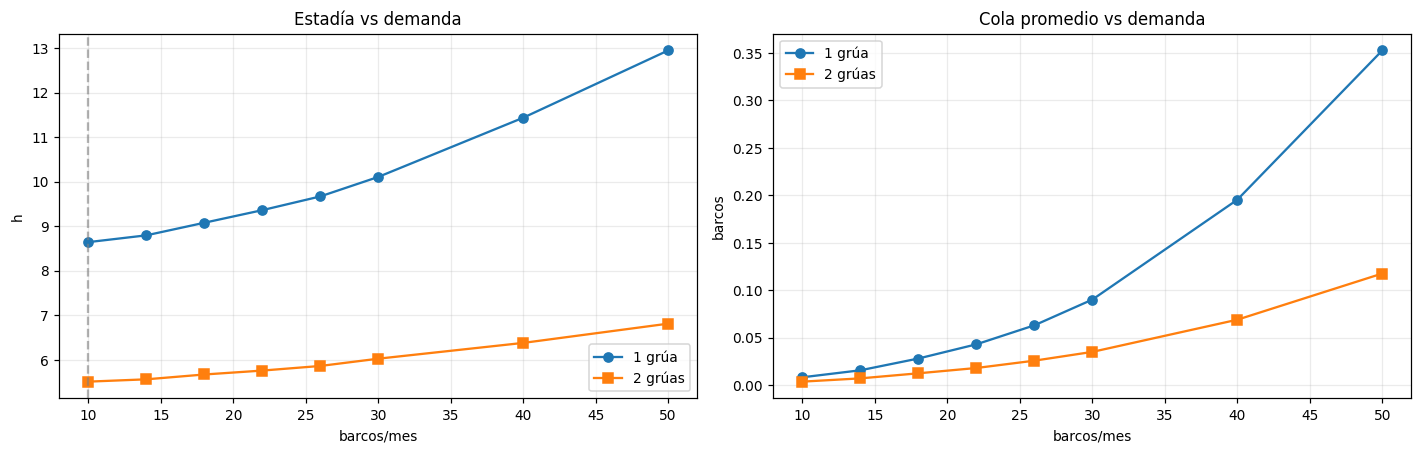

In [15]:
rates=[10,14,18,22,26,30,40,50]
out=[]
for rate in rates:
    Pr=dict(PAR); Pr['interarribo_min']=MONTH/rate
    r1=[run_one(Scenario(1,False),seed=s,P=Pr) for s in SEEDS]
    r2=[run_one(Scenario(2,False),seed=s,P=Pr) for s in SEEDS]
    out.append(dict(barcos_mes=rate,
        estadia_1g=np.mean([r['VR2_estadia_h'] for r in r1]),
        estadia_2g=np.mean([r['VR2_estadia_h'] for r in r2]),
        cola_1g=np.mean([r['VR5_cola_prom'] for r in r1]),
        cola_2g=np.mean([r['VR5_cola_prom'] for r in r2]),
        util_1g=np.mean([r['VR3_util'] for r in r1])))
stress=pd.DataFrame(out); display(stress.round(2))
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
ax[0].plot(stress.barcos_mes,stress.estadia_1g,'o-',label='1 grúa')
ax[0].plot(stress.barcos_mes,stress.estadia_2g,'s-',label='2 grúas')
ax[0].axvline(10,color='gray',ls='--',alpha=.6); ax[0].set_title("Estadía vs demanda"); ax[0].set_xlabel("barcos/mes"); ax[0].set_ylabel("h"); ax[0].legend()
ax[1].plot(stress.barcos_mes,stress.cola_1g,'o-',label='1 grúa')
ax[1].plot(stress.barcos_mes,stress.cola_2g,'s-',label='2 grúas')
ax[1].set_title("Cola promedio vs demanda"); ax[1].set_xlabel("barcos/mes"); ax[1].set_ylabel("barcos"); ax[1].legend()
plt.tight_layout(); plt.show()


**Conclusión VD1.** A la demanda actual (~10 barcos/mes) la segunda grúa **no resuelve un problema de congestión** (no lo hay): su efecto es **reducir ~36% la estadía** de cada barco por trabajar en paralelo. Incluso triplicando la demanda el puerto **sigue sin congestionarse** con una sola grúa. Por lo tanto, la segunda grúa se justifica **sólo si la reducción del tiempo de turnaround tiene valor comercial/contractual** (menos penalidades, mayor rotación), no como necesidad de capacidad.

## 7. VD2 — Tarifa diferencial por medio-contenedor

Un medio-contenedor consume más tiempo de grúa que uno lleno (media **18,5 vs 15,7 min ≈ +17,7%** por pieza). El simulador **mide** ese **sobrecosto de tiempo de grúa** atribuible a los medios (`VD2_extra_medios_h`), calculándolo como el tiempo real de cada medio menos el tiempo *esperado* de un lleno (no como la diferencia de modas, que lo sobreestimaría). Lo traducimos a una base tarifaria.

In [16]:
extra_h_anio = np.mean([r['VD2_extra_medios_h'] for r in RES['Base']])
cont_anio    = np.mean([r['VR4_cont_mes'] for r in RES['Base']])*12
medios_anio  = cont_anio*PAR['prop_half']
fa,fm,fb=PAR['grua_full']; ha,hm,hb=PAR['grua_half']
mean_full=(fa+fm+fb)/3.0; mean_half=(ha+hm+hb)/3.0
delta_min = mean_half-mean_full   # sobrecosto marginal ESPERADO = diferencia de MEDIAS (no de modas)
print(f"Contenedores movidos/año (Base) ≈ {cont_anio:.0f}  |  de los cuales medios ≈ {medios_anio:.0f}")
print(f"Sobrecosto de grúa por medio (media lleno {mean_full:.2f} → media medio {mean_half:.2f}) ≈ {delta_min:.2f} min  ({100*delta_min/mean_full:.0f}% más que un lleno)")
print(f"Tiempo de grúa extra/año por operar medios (MEDIDO en la sim) ≈ {extra_h_anio:.1f} h  (≈ {extra_h_anio/medios_anio*60:.1f} min/medio)")
print()
print("Base de la tarifa: el recargo por medio-contenedor debería cubrir el costo")
print(f"de ~{delta_min:.1f} min adicionales de grúa por pieza. Con un costo horario de grúa C ($/h),")
print(f"el recargo sugerido por medio ≈ C × {delta_min/60:.3f}  (más prorrateo de fallas/ociosidad).")


Contenedores movidos/año (Base) ≈ 2345  |  de los cuales medios ≈ 469
Sobrecosto de grúa por medio (media lleno 15.70 → media medio 18.48) ≈ 2.78 min  (18% más que un lleno)
Tiempo de grúa extra/año por operar medios (MEDIDO en la sim) ≈ 21.5 h  (≈ 2.7 min/medio)

Base de la tarifa: el recargo por medio-contenedor debería cubrir el costo
de ~2.8 min adicionales de grúa por pieza. Con un costo horario de grúa C ($/h),
el recargo sugerido por medio ≈ C × 0.046  (más prorrateo de fallas/ociosidad).


**Conclusión VD2.** El sobrecosto es **real y cuantificable**: cada medio-contenedor demanda ~2,8 min extra de grúa (+17,7% en media respecto de un lleno). Un recargo proporcional a ese tiempo adicional de grúa es **justificable y trazable a los datos**. Como la proporción de medios viene creciendo, el recargo además desincentiva el desplazamiento hacia el formato más costoso de operar.

## 8. VD3 — Mantenimiento preventivo

Supuesto declarado: el preventivo lleva MTBF×2,5 y MTTR×0,7. Comparamos Base vs B (pareado por CRN).

In [17]:
perdido_base=np.array([r['VR6_perdido_h'] for r in RES['Base']])
perdido_B   =np.array([r['VR6_perdido_h'] for r in RES['B']])
estadia_base=np.array([r['VR2_estadia_h'] for r in RES['Base']])
estadia_B   =np.array([r['VR2_estadia_h'] for r in RES['B']])
print(f"VR6 tiempo perdido por fallas: Base {perdido_base.mean():.1f} h/año → B {perdido_B.mean():.1f} h/año  "
      f"(−{100*(1-perdido_B.mean()/perdido_base.mean()):.0f}%)")
print(f"VR2 estadía:                  Base {estadia_base.mean():.2f} h → B {estadia_B.mean():.2f} h  "
      f"(−{100*(1-estadia_B.mean()/estadia_base.mean()):.0f}%)")


VR6 tiempo perdido por fallas: Base 110.2 h/año → B 30.7 h/año  (−72%)
VR2 estadía:                  Base 8.64 h → B 7.83 h  (−9%)


**Conclusión VD3.** El mantenimiento preventivo **ataca directamente la VR6**: reduce ~70% el tiempo perdido por fallas, con una mejora modesta de la estadía. Es la palanca **más barata y de mayor impacto sobre la disponibilidad** de la grúa; conviene priorizarla por sobre la inversión en una segunda grúa, dada la holgura de capacidad. *(El resultado depende del supuesto MTBF×2,5 / MTTR×0,7; conviene rehacerlo con datos del proveedor de mantenimiento si se dispone.)*

## 9. Conclusiones

1. **El puerto está sobredimensionado para su demanda actual.** Utilización de grúa ~7%, cola ~0, espera <1 h. El cuello de botella **no** es la capacidad.
2. **VD1 (segunda grúa):** no resuelve congestión (no la hay); reduce la **estadía** ~36% por paralelizar. Se justifica sólo si el turnaround más rápido tiene valor comercial. El stress test muestra que incluso a 3× la demanda el sistema sigue holgado con una sola grúa.
3. **VD3 (mantenimiento):** la mejor relación impacto/costo. Reduce ~70% el tiempo perdido por fallas (VR6, medida como **horas-grúa de indisponibilidad**, no como pérdida de throughput). **Recomendación prioritaria.** *(Con 2 grúas la VR6 total no baja —el trabajo, y por ende las horas operativas que gatillan fallas, se conserva—, pero su impacto sobre la estadía sí, porque la otra grúa sigue operando.)*
4. **VD2 (tarifa):** el sobrecosto de los medios es real (~+17,7% de tiempo de grúa por pieza, ~2,8 min) y trazable; un recargo proporcional es justificable.

**Recomendación de gestión:** priorizar el **mantenimiento preventivo** y aplicar la **tarifa diferencial**; **diferir la segunda grúa** salvo que existan compromisos de turnaround que la justifiquen comercialmente.